## 1. Import Libraries

In [77]:
import os
import sys
import random
from glob import glob
import matplotlib.pyplot as plt
import numpy as np
from tqdm.notebook import tqdm

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
from PIL import Image

# Add parent directory to path
sys.path.append('..')
from open_set.encoder_resnet import ResNetEmbedder

print(f"PyTorch version: {torch.__version__}")
print(f"CUDA available: {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"CUDA device: {torch.cuda.get_device_name(0)}")

PyTorch version: 2.9.1+cu128
CUDA available: True
CUDA device: NVIDIA GeForce RTX 4050 Laptop GPU


## 2. Configuration

In [78]:
# Training configuration
CONFIG = {
    'gei_root': '../gait/GEI',
    'save_path': 'encoder_resnet.pth',
    'epochs': 40,
    'batch_size': 16,
    'lr': 1e-4,
    'img_size': 224,
    'embedding_dim': 128,
    'margin': 0.3,
    'pretrained': False
}

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")
print("\nConfiguration:")
for k, v in CONFIG.items():
    print(f"  {k}: {v}")

Using device: cuda

Configuration:
  gei_root: ../gait/GEI
  save_path: encoder_resnet.pth
  epochs: 40
  batch_size: 16
  lr: 0.0001
  img_size: 224
  embedding_dim: 128
  margin: 0.3
  pretrained: False


## 3. Dataset Class

In [79]:
class GEIDataset(Dataset):
    """Dataset for GEI images organized as root_dir/{label}/*.png"""
    def __init__(self, root_dir, transform=None):
        self.items = []  # (path, label)
        labels = [d for d in os.listdir(root_dir) if os.path.isdir(os.path.join(root_dir, d))]
        labels = sorted(labels)
        self.label_map = {l: i for i, l in enumerate(labels)}
        self.label_names = labels
        
        for l in labels:
            files = sorted(glob(os.path.join(root_dir, l, '*.png')))
            for f in files:
                self.items.append((f, self.label_map[l]))
        
        self.transform = transform
    
    def __len__(self):
        return len(self.items)
    
    def __getitem__(self, idx):
        path, lbl = self.items[idx]
        img = Image.open(path).convert('L')
        if self.transform:
            img = self.transform(img)
        else:
            img = transforms.ToTensor()(img)
        return img, lbl

print("✓ GEIDataset class defined")

✓ GEIDataset class defined


## 4. Load and Explore Dataset

In [80]:
# Create dataset
transform = transforms.Compose([
    transforms.Resize((CONFIG['img_size'], CONFIG['img_size'])),
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,))
])

dataset = GEIDataset(CONFIG['gei_root'], transform=transform)

print(f"Dataset size: {len(dataset)} images")
print(f"Number of identities: {len(dataset.label_names)}")
print(f"Label names: {dataset.label_names}")

# Count samples per label
label_counts = {}
for _, lbl in dataset.items:
    label_counts[lbl] = label_counts.get(lbl, 0) + 1

print("\nSamples per identity:")
for lbl_idx, count in sorted(label_counts.items()):
    label_name = dataset.label_names[lbl_idx]
    print(f"  {label_name}: {count} images")

Dataset size: 325 images
Number of identities: 8
Label names: ['121', '122', '123', '124', 'Người thứ 2', 'Người thứ 3', 'Người thứ 4', 'Người thứ nhất']

Samples per identity:
  121: 25 images
  122: 23 images
  123: 27 images
  124: 23 images
  Người thứ 2: 43 images
  Người thứ 3: 74 images
  Người thứ 4: 45 images
  Người thứ nhất: 65 images


In [81]:
# --- Split dataset into train/val (80/20) ---
from torch.utils.data import random_split

val_ratio = 0.2
val_size = int(len(dataset) * val_ratio)
train_size = len(dataset) - val_size
train_dataset, val_dataset = random_split(dataset, [train_size, val_size])

train_loader = DataLoader(train_dataset, batch_size=CONFIG['batch_size'], shuffle=True, drop_last=True)
val_loader = DataLoader(val_dataset, batch_size=CONFIG['batch_size'], shuffle=False, drop_last=False)

print(f"Train size: {len(train_dataset)} images")
print(f"Val size: {len(val_dataset)} images")

Train size: 260 images
Val size: 65 images


## 5. Visualize Sample GEI Images

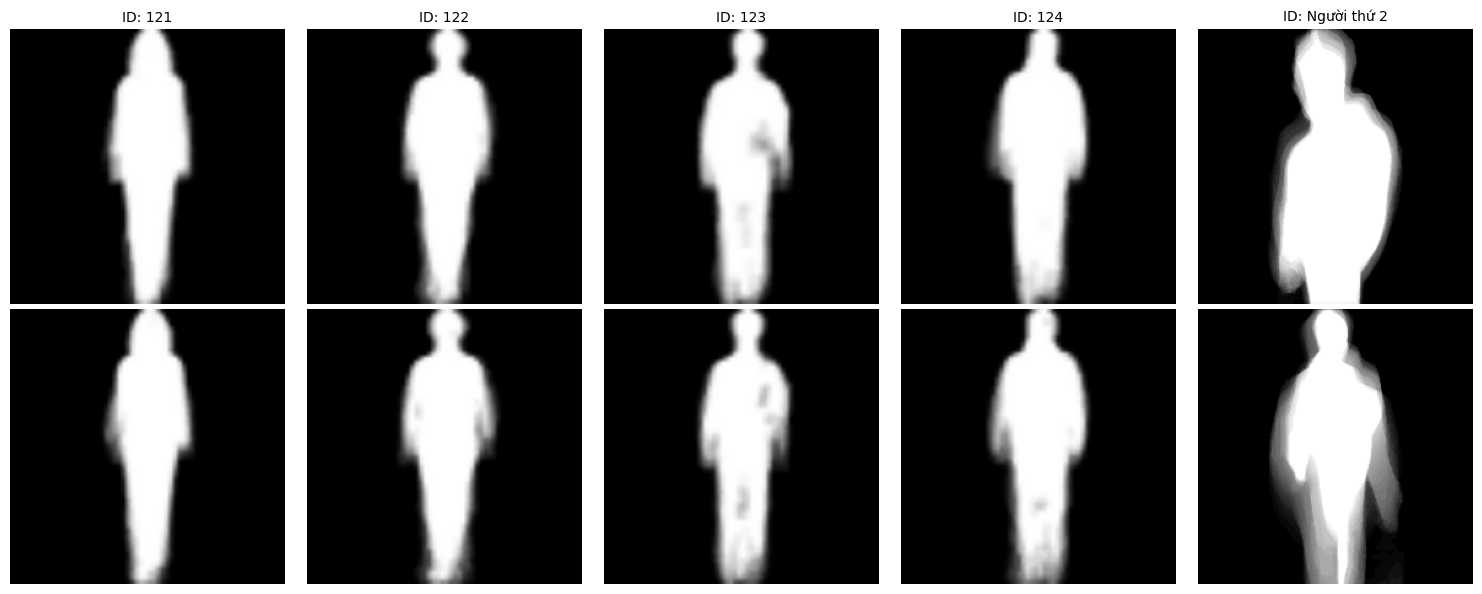

In [82]:
# Show sample images from each identity
fig, axes = plt.subplots(2, min(5, len(dataset.label_names)), figsize=(15, 6))
if len(dataset.label_names) == 1:
    axes = np.array([axes]).reshape(-1, 1)

for i, label_name in enumerate(dataset.label_names[:5]):
    label_idx = dataset.label_map[label_name]
    # Get samples for this label
    samples = [idx for idx, (_, lbl) in enumerate(dataset.items) if lbl == label_idx]
    
    for j in range(2):
        if j < len(samples):
            img, _ = dataset[samples[j]]
            ax = axes[j, i] if len(dataset.label_names) > 1 else axes[j]
            ax.imshow(img.squeeze(), cmap='gray')
            ax.axis('off')
            if j == 0:
                ax.set_title(f'ID: {label_name}', fontsize=10)

plt.tight_layout()
plt.show()

## 6. Triplet Mining Function

In [83]:
def make_triplets(batch_labels):
    """Generate triplets from a batch of labels"""
    idx_per_label = {}
    for i, l in enumerate(batch_labels):
        idx_per_label.setdefault(l, []).append(i)
    
    anchors, positives, negatives = [], [], []
    for i, l in enumerate(batch_labels):
        pos_choices = idx_per_label.get(l, [])
        if len(pos_choices) <= 1:
            continue
        pos = random.choice([p for p in pos_choices if p != i])
        neg_label = random.choice([ll for ll in idx_per_label.keys() if ll != l])
        neg = random.choice(idx_per_label[neg_label])
        anchors.append(i)
        positives.append(pos)
        negatives.append(neg)
    
    return anchors, positives, negatives

print("✓ Triplet mining function defined")

✓ Triplet mining function defined


## 7. Initialize Model and Training Components

In [84]:
# Create dataloader
loader = DataLoader(dataset, batch_size=CONFIG['batch_size'], shuffle=True, drop_last=True)

# Initialize model
model = ResNetEmbedder(
    embedding_dim=CONFIG['embedding_dim'],
    pretrained=CONFIG['pretrained'],
    grayscale=True
)
model.to(device)

# Optimizer and loss
optimizer = torch.optim.Adam(model.parameters(), lr=CONFIG['lr'])
criterion = nn.TripletMarginLoss(margin=CONFIG['margin'])

print(f"✓ Model initialized with {sum(p.numel() for p in model.parameters())/1e6:.2f}M parameters")
print(f"✓ Optimizer: Adam (lr={CONFIG['lr']})")
print(f"✓ Loss: TripletMarginLoss (margin={CONFIG['margin']})")

c:\Users\ADMIN\anaconda3\envs\train_model\Lib\site-packages\torchvision\models\_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
c:\Users\ADMIN\anaconda3\envs\train_model\Lib\site-packages\torchvision\models\_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=None`.
  warnings.warn(msg)


✓ Model initialized with 11.24M parameters
✓ Optimizer: Adam (lr=0.0001)
✓ Loss: TripletMarginLoss (margin=0.3)


## 8. Training Loop

In [85]:
# Training history
history = {'loss': [], 'epoch': []}

print("Starting training...\n")

for epoch in range(CONFIG['epochs']):
    model.train()
    epoch_loss = 0.0
    num_batches = 0
    
    pbar = tqdm(loader, desc=f"Epoch {epoch+1}/{CONFIG['epochs']}")
    for imgs, labels in pbar:
        imgs = imgs.to(device)
        labels = labels.numpy().tolist()
        
        # Forward pass
        emb = model(imgs)
        
        # Generate triplets
        a_idx, p_idx, n_idx = make_triplets(labels)
        if len(a_idx) == 0:
            continue
        
        anc = emb[a_idx]
        pos = emb[p_idx]
        neg = emb[n_idx]
        
        # Compute loss
        loss = criterion(anc, pos, neg)
        
        # Backward pass
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        
        epoch_loss += loss.item()
        num_batches += 1
        
        pbar.set_postfix({'loss': f'{loss.item():.4f}'})
    
    avg_loss = epoch_loss / max(num_batches, 1)
    history['loss'].append(avg_loss)
    history['epoch'].append(epoch + 1)
    
    print(f"Epoch {epoch+1}/{CONFIG['epochs']} - Average Loss: {avg_loss:.4f}")

print("\n✓ Training completed!")

Starting training...



Epoch 1/40:   0%|          | 0/20 [00:00<?, ?it/s]

Epoch 1/40 - Average Loss: 0.1984


Epoch 2/40:   0%|          | 0/20 [00:00<?, ?it/s]

Epoch 2/40 - Average Loss: 0.0819


...

Epoch 38/40 - Average Loss: 0.0055


Epoch 39/40:   0%|          | 0/20 [00:00<?, ?it/s]

Epoch 39/40 - Average Loss: 0.0023


Epoch 40/40:   0%|          | 0/20 [00:00<?, ?it/s]

Epoch 40/40 - Average Loss: 0.0037

✓ Training completed!


## 9. Visualize Training Progress

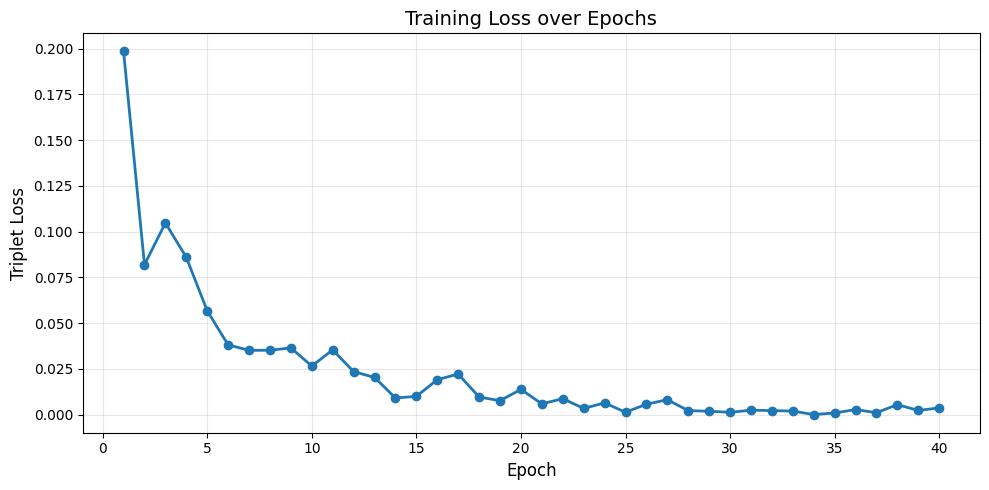

Final loss: 0.0037
Best loss: 0.0000 at epoch 34


In [86]:
# Plot training loss
plt.figure(figsize=(10, 5))
plt.plot(history['epoch'], history['loss'], marker='o', linewidth=2)
plt.xlabel('Epoch', fontsize=12)
plt.ylabel('Triplet Loss', fontsize=12)
plt.title('Training Loss over Epochs', fontsize=14)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print(f"Final loss: {history['loss'][-1]:.4f}")
print(f"Best loss: {min(history['loss']):.4f} at epoch {history['epoch'][np.argmin(history['loss'])]}")

## 10. Visualize Embeddings

In [87]:
# Extract embeddings for visualization
model.eval()
all_embeddings = []
all_labels = []

with torch.no_grad():
    for imgs, labels in tqdm(loader, desc="Extracting embeddings"):
        imgs = imgs.to(device)
        emb = model(imgs)
        all_embeddings.append(emb.cpu().numpy())
        all_labels.extend(labels.numpy().tolist())

all_embeddings = np.vstack(all_embeddings)
all_labels = np.array(all_labels)

print(f"Embeddings shape: {all_embeddings.shape}")
print(f"Labels shape: {all_labels.shape}")

Extracting embeddings:   0%|          | 0/20 [00:00<?, ?it/s]

Embeddings shape: (320, 128)
Labels shape: (320,)


Computing t-SNE...


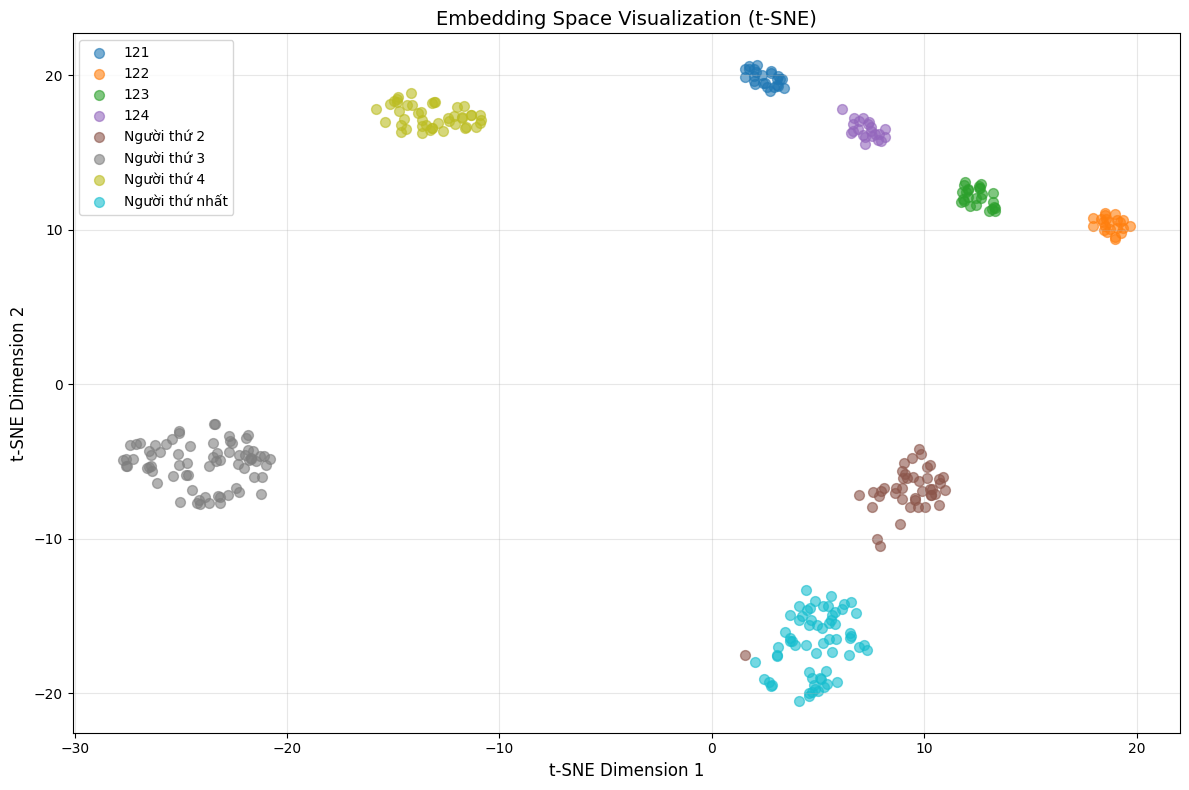

In [88]:
# t-SNE visualization
from sklearn.manifold import TSNE

print("Computing t-SNE...")
tsne = TSNE(n_components=2, random_state=42, perplexity=min(30, len(all_embeddings)-1))
embeddings_2d = tsne.fit_transform(all_embeddings)

# Plot
plt.figure(figsize=(12, 8))
colors = plt.cm.tab10(np.linspace(0, 1, len(dataset.label_names)))

for i, label_name in enumerate(dataset.label_names):
    mask = all_labels == i
    plt.scatter(embeddings_2d[mask, 0], embeddings_2d[mask, 1], 
               c=[colors[i]], label=label_name, s=50, alpha=0.6)

plt.xlabel('t-SNE Dimension 1', fontsize=12)
plt.ylabel('t-SNE Dimension 2', fontsize=12)
plt.title('Embedding Space Visualization (t-SNE)', fontsize=14)
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## 11. Compute Embedding Statistics

C:\Users\ADMIN\AppData\Local\Temp\ipykernel_19952\2898425384.py:35: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot([intra_distances, inter_distances], labels=['Intra-class', 'Inter-class'])


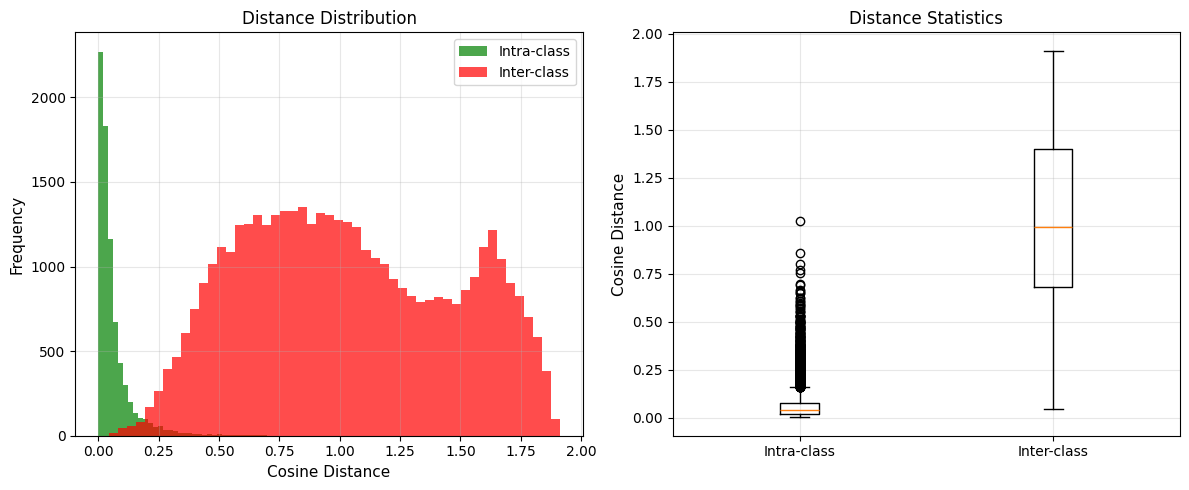

Intra-class distance: 0.0632 ± 0.0786
Inter-class distance: 1.0340 ± 0.4326
Separation ratio: 16.36x


In [89]:
from scipy.spatial.distance import cdist

# Compute pairwise distances
distances = cdist(all_embeddings, all_embeddings, metric='cosine')

# Intra-class distances (same person)
intra_distances = []
for label in range(len(dataset.label_names)):
    mask = all_labels == label
    if mask.sum() > 1:
        label_dists = distances[mask][:, mask]
        # Get upper triangle (exclude diagonal)
        intra_distances.extend(label_dists[np.triu_indices_from(label_dists, k=1)])

# Inter-class distances (different person)
inter_distances = []
for i in range(len(all_labels)):
    for j in range(i+1, len(all_labels)):
        if all_labels[i] != all_labels[j]:
            inter_distances.append(distances[i, j])

# Plot distributions
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.hist(intra_distances, bins=50, alpha=0.7, label='Intra-class', color='green')
plt.hist(inter_distances, bins=50, alpha=0.7, label='Inter-class', color='red')
plt.xlabel('Cosine Distance', fontsize=11)
plt.ylabel('Frequency', fontsize=11)
plt.title('Distance Distribution', fontsize=12)
plt.legend()
plt.grid(True, alpha=0.3)

plt.subplot(1, 2, 2)
plt.boxplot([intra_distances, inter_distances], labels=['Intra-class', 'Inter-class'])
plt.ylabel('Cosine Distance', fontsize=11)
plt.title('Distance Statistics', fontsize=12)
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print(f"Intra-class distance: {np.mean(intra_distances):.4f} ± {np.std(intra_distances):.4f}")
print(f"Inter-class distance: {np.mean(inter_distances):.4f} ± {np.std(inter_distances):.4f}")
print(f"Separation ratio: {np.mean(inter_distances) / np.mean(intra_distances):.2f}x")

## 12. Save Model

In [90]:
# Save model checkpoint
save_path = CONFIG['save_path']
torch.save(model.state_dict(), save_path)
print(f"✓ Model saved to: {save_path}")

# Also save full checkpoint with optimizer state
checkpoint_path = save_path.replace('.pth', '_checkpoint.pth')
torch.save({
    'epoch': CONFIG['epochs'],
    'model_state_dict': model.state_dict(),
    'optimizer_state_dict': optimizer.state_dict(),
    'loss': history['loss'][-1],
    'config': CONFIG,
    'history': history
}, checkpoint_path)
print(f"✓ Full checkpoint saved to: {checkpoint_path}")

✓ Model saved to: encoder_resnet.pth
✓ Full checkpoint saved to: encoder_resnet_checkpoint.pth


## 13. Test Loading Model

In [91]:
# Test loading the saved model
test_model = ResNetEmbedder(
    embedding_dim=CONFIG['embedding_dim'],
    pretrained=False,
    grayscale=True
)
test_model.load_state_dict(torch.load(save_path))
test_model.to(device)
test_model.eval()

print("✓ Model loaded successfully!")

# Test inference
test_img, test_label = dataset[0]
with torch.no_grad():
    test_emb = test_model(test_img.unsqueeze(0).to(device))
    print(f"Test embedding shape: {test_emb.shape}")
    print(f"Test embedding norm: {torch.norm(test_emb).item():.4f}")

c:\Users\ADMIN\anaconda3\envs\train_model\Lib\site-packages\torchvision\models\_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
c:\Users\ADMIN\anaconda3\envs\train_model\Lib\site-packages\torchvision\models\_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=None`.
  warnings.warn(msg)


✓ Model loaded successfully!
Test embedding shape: torch.Size([1, 128])
Test embedding norm: 1.0000


## 14. Create Database.json

In [92]:
# Extract embeddings for all samples
model.eval()
all_embeddings = []
all_labels = []

print("Extracting embeddings for database...")
with torch.no_grad():
    for i, (img, label) in enumerate(dataset):
        emb = model(img.unsqueeze(0).to(device))
        all_embeddings.append(emb.cpu().numpy()[0])
        # Lưu tên label thực (string) thay vì số
        label_name = dataset.label_names[label]
        all_labels.append(label_name)
        
all_embeddings = np.array(all_embeddings)
all_labels = np.array(all_labels)

print(f"✓ Extracted {len(all_embeddings)} embeddings")
print(f"  Embedding shape: {all_embeddings.shape}")
print(f"  Unique labels: {np.unique(all_labels)}")

Extracting embeddings for database...
✓ Extracted 325 embeddings
  Embedding shape: (325, 128)
  Unique labels: ['121' '122' '123' '124' 'Người thứ 2' 'Người thứ 3' 'Người thứ 4'
 'Người thứ nhất']


In [93]:
# Save to JSON format for run_open_set.py
import json

embeddings_json = {
    'embeddings': all_embeddings.tolist(),
    'labels': all_labels.tolist()
}

json_output = '../gait/embeddings.json'
with open(json_output, 'w', encoding='utf-8') as f:
    json.dump(embeddings_json, f, indent=2)

print(f"✓ Saved embeddings to: {json_output}")
print(f"  Can now run: python run_open_set.py {json_output} --output_db database.json")

✓ Saved embeddings to: ../gait/embeddings.json
  Can now run: python run_open_set.py ../gait/embeddings.json --output_db database.json


In [94]:
# Or directly create database.json using run_open_set module
import sys
sys.path.append('..')
from run_open_set import run_from_json

database_output = '../database.json'
run_from_json(
    json_output, 
    output_db=database_output,
    metric='cosine',
    percentile=99.5,  # Tăng từ 95 lên 99.5 để chấp nhận variance từ real-time video
    alpha=3.0
)

print(f"\n✓ Database created: {database_output}")
print(f"  Percentile=99.5 → thresholds sẽ cao hơn để chấp nhận GEI từ video")

Removed existing database: ../database.json
✅ Đã lưu 2 Prototypes tối ưu cho User '121' vào ../database.json
✅ Đã lưu 3 Prototypes tối ưu cho User '122' vào ../database.json
✅ Đã lưu 2 Prototypes tối ưu cho User '123' vào ../database.json
✅ Đã lưu 2 Prototypes tối ưu cho User '124' vào ../database.json
✅ Đã lưu 4 Prototypes tối ưu cho User 'Người thứ 2' vào ../database.json
✅ Đã lưu 3 Prototypes tối ưu cho User 'Người thứ 3' vào ../database.json
✅ Đã lưu 2 Prototypes tối ưu cho User 'Người thứ 4' vào ../database.json
✅ Đã lưu 3 Prototypes tối ưu cho User 'Người thứ nhất' vào ../database.json
Wrote prototypes to ../database.json

✓ Database created: ../database.json
  Percentile=99.5 → thresholds sẽ cao hơn để chấp nhận GEI từ video


In [95]:
# --- Đánh giá độ chính xác trên tập validation bằng OpenSetMatcher ---
from open_set_matcher import OpenSetGaitMatcher

matcher = OpenSetGaitMatcher(filename="../database.json")

correct = 0
total = 0
unknown = 0
model.eval()
for img, label in val_dataset:
    # Chuyển ảnh sang batch 1x1xHxW nếu cần
    if hasattr(img, 'unsqueeze'):
        img = img.unsqueeze(0)
    emb = model(img.to(device)).detach().cpu().numpy()[0]
    result = matcher.predict(emb)
    label_name = dataset.label_names[label]
    print(f"\n===Gait Recognition Result for label '{label_name}'===")
    print(f"  User ID: {result['user_id']}")
    print(f"  Distance: {result['distance']:.4f}")
    print(f"  Threshold: {result.get('threshold', 'N/A')}")
    print(f"  Is Known: {result['is_known']}")
    if result['is_known'] and str(result['user_id']) == label_name:
        correct += 1
        print("  → Correct match!")
    else:
        print("  → Incorrect match.")
    if not result['is_known']:
        unknown += 1
    total += 1

acc = correct / total if total > 0 else 0
print(f"Validation accuracy (OpenSetMatcher): {acc:.4f} ({correct}/{total})")
print(f"Validation accuracy (Known only): {correct / (total - unknown) if (total - unknown) > 0 else 0:.4f} ({correct}/{total - unknown})")
print(f"Unknown predictions: {unknown} out of {total}")


===Gait Recognition Result for label '123'===
  User ID: 123
  Distance: 0.0401
  Threshold: 0.10939433211786012
  Is Known: True
  → Correct match!

===Gait Recognition Result for label 'Người thứ 4'===
  User ID: Người thứ 4
  Distance: 0.0051
  Threshold: 0.010303967095359747
  Is Known: True
  → Correct match!

===Gait Recognition Result for label 'Người thứ nhất'===
  User ID: Người thứ nhất
  Distance: 0.0145
  Threshold: 0.06168034627369567
  Is Known: True
  → Correct match!

===Gait Recognition Result for label 'Người thứ nhất'===
  User ID: Người thứ nhất
  Distance: 0.0085
  Threshold: 0.06168034627369567
  Is Known: True
  → Correct match!

===Gait Recognition Result for label 'Người thứ nhất'===
  User ID: Người thứ nhất
  Distance: 0.0100
  Threshold: 0.06168034627369567
  Is Known: True
  → Correct match!

===Gait Recognition Result for label 'Người thứ 2'===
  User ID: Người thứ 2
  Distance: 0.0290
  Threshold: 0.099261560274332
  Is Known: True
  → Correct match!

==